标准的 PyTorch 工作流程

| Topic | Contents |
| :--- | :--- |
| 1. 准备数据 | 数据几乎可以是任何东西，但要开始，我们将创建一条简单的直线 |
| 2. 创建模型 | 创建模型来学习数据，需要选择 **损失函数 (loss function)**、优化器 (optimizer) 构建训练循环 (training loop)。 |
| 3. 将模型拟合到数据 训练(training) | 有了数据和模型，现在让模型在 (**训练 (training)**) 中找到数据的模式。 |
| 4. 推测和评价模型(推断(inference)) | 模型学习到模式后，用模型进行预测，并和实际数据比较 (**测试 (testing)**) |
| 5. 保存和加载模型 | 先保存模型，未来再加载模型。 |
| 6. 组合起来 | 将上面的步骤组合起来。 |

In [1]:
%matplotlib inline

import torch
import matplotlib.pyplot as plt
import torch.nn as nn



# Check PyTorch version
torch.__version__

'2.10.0+cu130'

## 1. Data(preparing and loading

机器学习中的数据几乎可以是你能想象到的任何东西

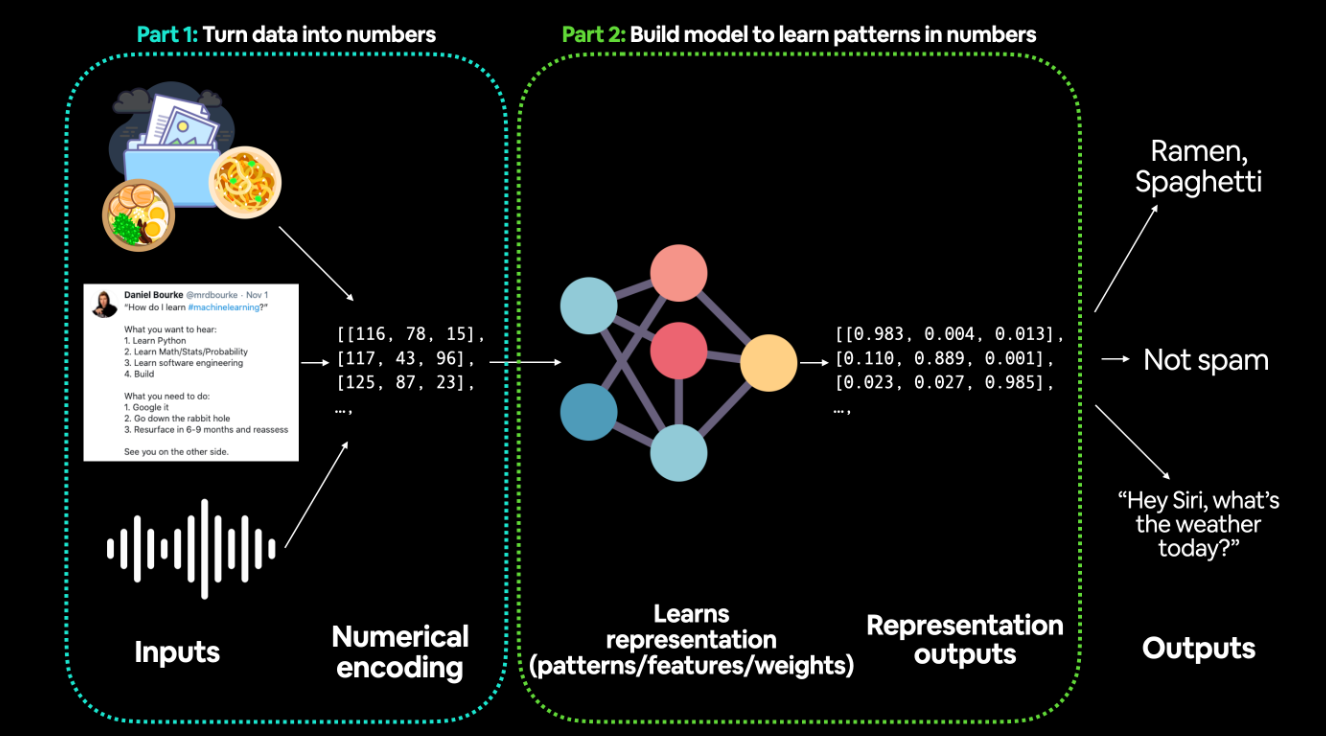

机器学习主要有两部分:
- 将数据转换成合适的数字形式(a representation).
- 选择合适的模型去学习数据的形式。

用线性回归作为例子，设置参数然后使用pytorch构造模型通过梯度下降学习参数

In [2]:
# Create known parameters
weight = 0.7
bias = 0.3

#Create data
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(1)
y = weight * X + bias

print(X[:10])
print(y[:10])


tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800]])
tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
        [0.3700],
        [0.3840],
        [0.3980],
        [0.4120],
        [0.4260]])


构建模型学习x(features)和y(labels)的关系

### 1.1 分割数据为训练集和测试集(train,val,test sets)

| Split           | Purpose                                                                                             | Amount of total data | How often is it used? |
|-----------------|-----------------------------------------------------------------------------------------------------|----------------------|-----------------------|
| Training set    | 模型从这些数据中学习（比如你在学期中学习的课程材料）。                                           | ~60-80%              | Always                |
| Validation set  | 该模型会根据这些数据进行调整（例如您在期末考试前参加的练习考试）。                                 | ~10-20%              | Often but not always  |
| Testing set     | 模型会根据这些数据进行评估，以测试它学到了什么（比如你在学期末参加的期末考试）。                   | ~10-20%              | Always                |

在处理真实世界的数据时，这一步通常在项目开始时完成（测试集应始终与所有其他数据分开）。 我们希望我们的模型在训练数据上进行学习，然后在测试数据上对其进行评估，以了解它对未见示例的泛化程度。.

In [3]:
#Create train/test split
train_split = int(0.8 * len(X))
X_train, X_test = X[:train_split], X[train_split:]
y_train, y_test = y[:train_split], y[train_split:]
print(len(X_train), len(X_test))
print(len(y_train), len(y_test))

40 10
40 10


有了40个训练样本 (X_train & y_train) 和10个测试样本(X_test & y_test),就可以创建模型学习X_train 和 y_train的关系 并在 X_test 和 y_test测试学习效果。在创建模型之前可以对数据进行可视化（便于更好了解数据）。

In [6]:
def plot_predictions():
    # 创建画布
    plt.figure(figsize=(10, 7))
    # 绘制训练数据（蓝色）
    plt.scatter(X_train, y_train, c="b", s=4, label="train data")
    # 绘制测试数据（绿色）
    plt.scatter(X_test, y_test, c="g", s=4, label="test data")
    # 显示图例
    plt.legend(prop={'size': 14})
    # 强制显示图像
    plt.show()

## 2. 创建模型

建立一个模型来训练权重

In [ ]:
plot_predictions()

In [4]:
# Create a Linear Regression model class
class LinearRegressionModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.weight = torch.nn.Parameter(torch.randn(1,# <- 从随机权重开始
                                                     requires_grad=True,# <- 是否可以用梯度下降（gradient descent）更新?
                                                     dtype=torch.float))# <- PyTorch loves float32 by default
        self.bias = torch.nn.Parameter(torch.randn(1,# <- start with random bias (this will get adjusted as the model learns)
                                                   requires_grad=True,# <- can we update this value with gradient descent?
                                                   dtype=torch.float))# <- PyTorch loves float32 by default
    def forward(self, x: torch.Tensor) -> torch.Tensor:# <- "x" is the input data (e.g. training/testing features)
        return self.weight * x + self.bias# <- this is the linear regression formula (y = m*x + b)

### 2.1 PyTorch模型构建要点

pytorch有四个模块

| PyTorch 模块          | 功能说明                                                                 |
|-----------------------|--------------------------------------------------------------------------|
| `torch.nn`            | 包含计算图的所有核心构建模块，本质上是按特定逻辑执行的一系列计算操作。|
| `torch.nn.Parameter`  | 存储可被 `nn.Module` 调用的张量。若设置 `requires_grad=True`，会自动计算梯度（用于通过梯度下降更新模型参数），该过程即“自动求导（autograd）”。 |
| `torch.nn.Module`     | PyTorch 中所有神经网络模块的基类，所有网络组件均继承于此。自定义神经网络模型时，必须继承该类并实现 `forward()` 方法。 |
| `torch.optim`         | 提供各类优化算法，定义如何优化更新 `nn.Parameter` 中存储的模型参数，以此优化梯度下降过程、降低损失值（loss）。 |
| `def forward()`       | 所有 `nn.Module` 子类的必实现方法，用于定义输入数据在 `nn.Module` 中执行的计算逻辑（如线性回归公式的运算）。 |

 - `nn.Module` : 模型基类
 - `nn.Prarmeter` : 可训练参数
 - `forward()` : 前向传播
 - `torch.optim` : 优化器

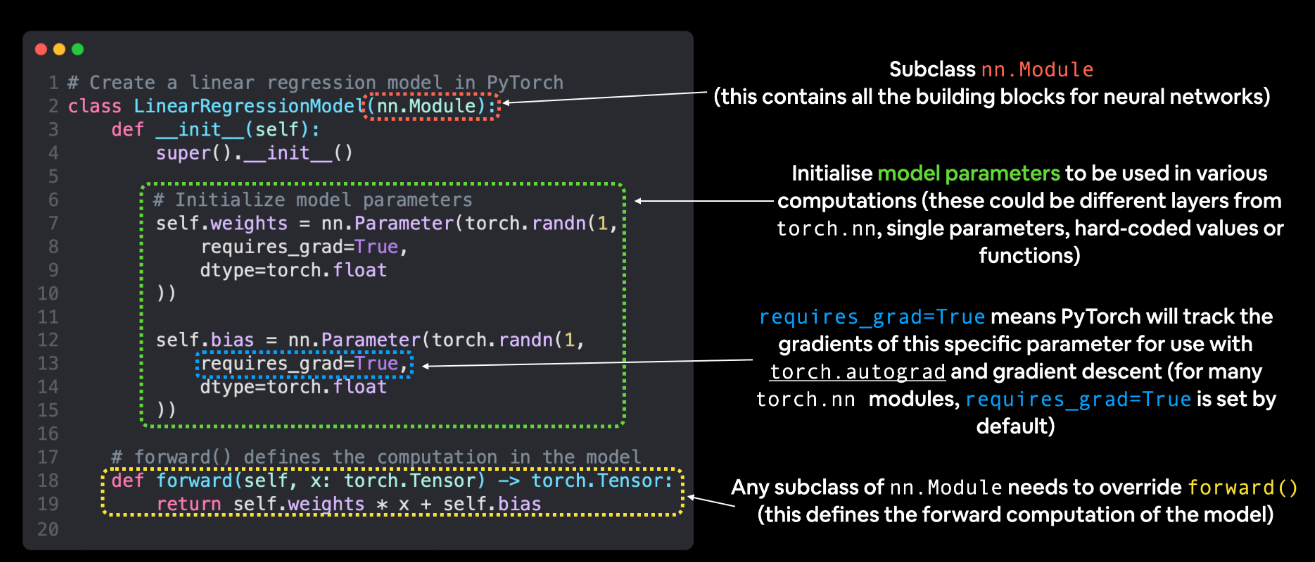

### 2.2 检查PyTorch模型的内容

用创建的类创建一个模型实例，并使用 .parameters() 检查它的参数。

In [5]:
# Set manual seed since nn.Parameter are randomly initialzied
torch.manual_seed(42)
# Create an instance of the model
model_0 = LinearRegressionModel()
# Check the nn.Parameter within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

可以用`.state_dict()`获得模型状态

In [6]:
model_0.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

这里的weights和bias是随机tensor，因为是用torch.randn()随机初始化参数
本质上，我们希望从随机参数开始，让模型将它们更新为最适合我们数据的参数

### 2.3 用```torch.inference_mode()```预测

传递```X_test```来看预测结果和```y_test```的区别
传递数据给模型，数据会经过```forward()```然后得到结果

In [7]:
model_0.eval()
with torch.inference_mode():
    y_preds = model_0.forward(X_test)
    print(y_preds)

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


```torch.inference_mode()```是 PyTorch 专门给【模型预测 / 推理】用的优化开关,用```with torch inference_mode()```包裹预测代码。必须搭配 model.eval()
- ```model.eval()```：改模型层的行为（dropout 不生效、BN 用统计均值）
- ```torch.inference_mode()```：改计算引擎的行为（禁用梯度、加速）
两个一起用，才是完整的推理配置。

- 进入 with 代码块时：自动开启某个功能 / 设置
- 离开 with 代码块时：自动关闭 / 还原，不用手动写代码清理

In [11]:
print(f"Number of testing samples: {len(X_test)}")
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


In [ ]:
plot_predictions()

In [12]:
print(y_test - y_preds)

tensor([[0.4618],
        [0.4691],
        [0.4764],
        [0.4836],
        [0.4909],
        [0.4982],
        [0.5054],
        [0.5127],
        [0.5200],
        [0.5272]])


这个例子一个x对应一个y，在其他情况下，一个y可能有很多x

## 3. train model

以上的模型使用随机参数进行预测，基本上是随机猜测的。可以更新它的内部参数，使用```nn.Parameter()```和```Torch.randn()```随机设置的```weights```和```bias```值将更好地代表数据。

### 3.1 创建损失函数和优化器

为了模型自行更新参数，需要损失函数和优化器

| Function          | What does it do?                                                                 | Where does it live in PyTorch? | Common values                                                                                                 |
|-------------------|---------------------------------------------------------------------------------|--------------------------------|----------------------------------------------------------------------------------------------------------------|
| **Loss function** | 计算你的预测 (e.g. `y_preds`) 与实际标签 (e.g. `y_test`) 的误差。误差越小越好。 | PyTorch有许多内置损失函数 `torch.nn.` | Mean absolute error (MAE,平均绝对误差) 用于回归 (regression) 问题: (`torch.nn.L1Loss()`).<br>Binary cross entropy (二元交叉熵) 用于二分类问题: (`torch.nn.BCELoss()`). |
| **Optimizer**     | 告诉您的模型如何更新其内部参数以最好地降低损失。                               | 可以在PyTorch中找到许多优化器: `torch.optim.` | Stochastic gradient descent (`torch.optim.SGD()`).<br>Adam optimizer (`torch.optim.Adam()`).                   |

SGD（随机梯度下降）或 Adam 优化器。，以及用于回归问题（预测数字）的 MAE（平均绝对误差）损失函数，用于分类问题（预测一件事或另一件事）的二元交叉熵损失函数。

 预测数字， 可以使用MAE (```torch.nn.L1Loss()```)计算两个点（预测值和标签）之间的绝对差值，然后对所有样本取平均值

然后使用SGD,```torch.optim.SGD(params, lr)```
- params 是需要优化的模型参数
- lr 是更新参数时的learning rate（学习率） , 学习率越大则参数更新的幅度越大 (太大时，优化器可能会失效), 学习率越小则参数更新的幅度越小 (太小时，优化器会花非常多的时间优化). 学习率是一个 hyperparamter（超参数） (由我们人为设置). 常用的学习率有 0.01, 0.001, 0.0001, 有时可能花费很多时间调整

In [8]:
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)

### 3.2 创建优化循环

- 训练循环中，模型遍历训练数据并学习features和labels之间的关系。
    | Number | Step name                     | What does it do?                                                                                                 | Code example                         |
|--------|-------------------------------|------------------------------------------------------------------------------------------------------------------|--------------------------------------|
| 1      | Forward pass                  | 模型遍历训练数据, 使用 `forward()` 方法计算。                                                                     | `model(x_train)`                     |
| 2      | 计算 loss                     | 计算模型的输出 (预测) 与实际值的差                                                                                 | `loss = loss_fn(y_pred, y_train)`    |
| 3      | 梯度清零                      | 优化器梯度设置为零 (默认梯度会累加) 因此可以针对特定的训练步骤重新计算它们                                           | `optimizer.zero_grad()`              |
| 4      | 在loss上反向传播              | 计算每个要更新的模型参数的损失梯度(each parameter with `requires_grad=True`). 称为 **backpropagation** (反向传播), "backwards". | `loss.backward()`                    |
| 5      | 更新优化器 (gradient descent) | 通过损失的梯度更新 `requires_grad=True` 的模型参数                                                                 | `optimizer.step()`                   |

    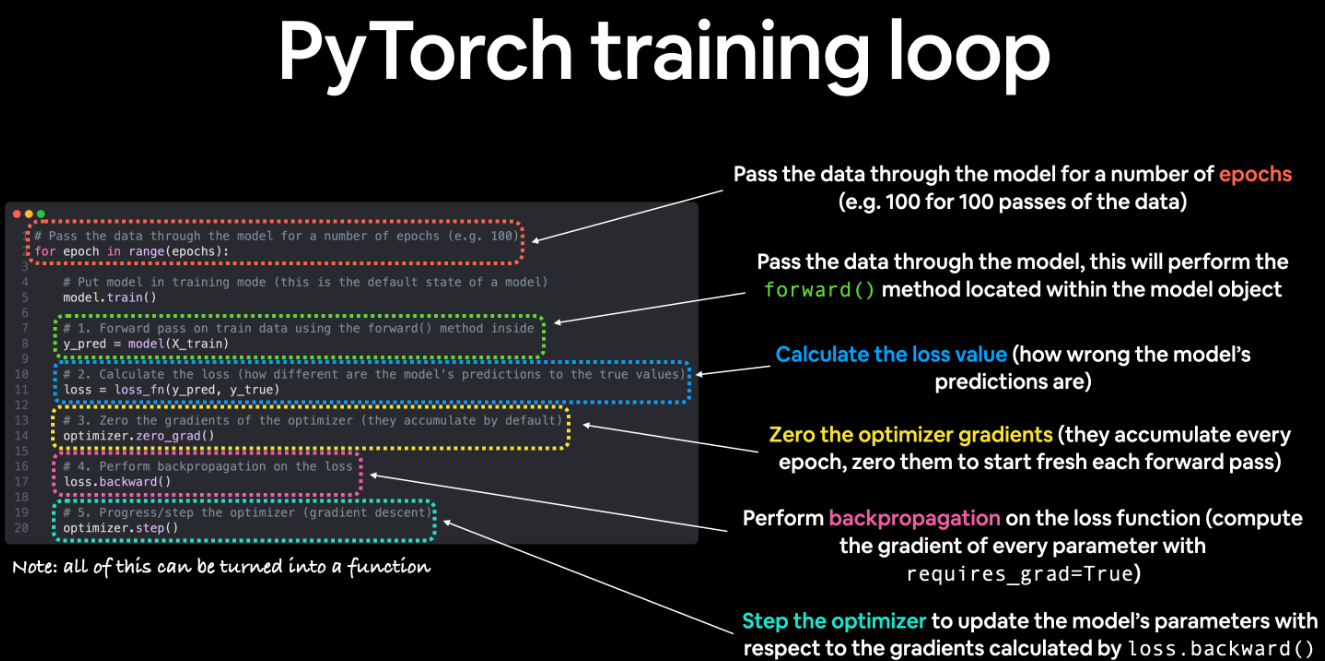

- 测试循环中，遍历测试数据并评估模型在训练数据上学习的模式有多好（模型在训练期间永远不会看到测试数据）。

    | Number | Step name               | What does it do?                                                                                                 | Code example                     |
    |--------|-------------------------|------------------------------------------------------------------------------------------------------------------|----------------------------------|
    | 1      | Forward pass            | 模型遍历全部训练数据一次，执行其 `forward()` 函数的计算。                                                         | `model(x_test)`                  |
    | 2      | 计算损失                | 将模型的输出（预测值）与真实标签（ground truth）进行对比，评估预测的误差程度。                                       | `loss = loss_fn(y_pred, y_test)` |
    | 3      | 计算评价指标（可选）    | 除损失值外，你还可以在测试集上计算其他评价指标，例如准确率。                                                         | Custom functions                 |

    test循环中没有反向传播 (loss.backward()) 因为测试时模型的参数不该变化。测试时只在意模型的输出

    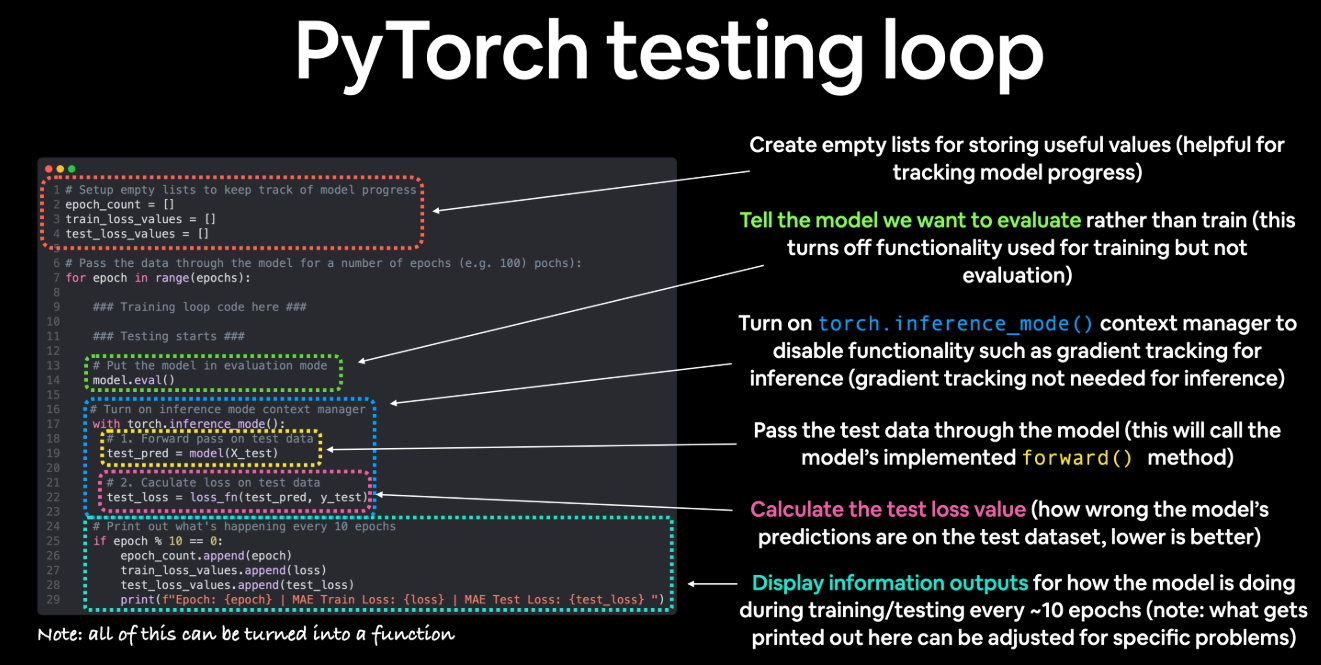

将上面步骤结合起来，训练 100个 epochs ，并且 每10epochs评估一次

In [10]:
torch.manual_seed(42)
epochs = 100

#创建空损失列表，追踪values值
train_loss_values = []
test_loss_values = []
epoch_counts = []
for epoch in range(epochs):
    ###训练

    # 把模型放入训练模型（默认步骤）
    model_0.train()

    # 1. 使用内部的 forward () 方法对训练数据进行前向传播
    y_preds = model_0.forward(X_train)

    # 2. 计算损失（预测值和真实值之间）
    loss = loss_fn(y_preds, y_train)

    # 3. 清空优化器的梯度
    optimizer.zero_grad()

    # 4. 损失反向传播,计算累计梯度
    loss.backward()

    # 5. 使用优化器更新参数，根据梯度修改参数模型
    optimizer.step()

    #模型评估
    model_0.eval()

    with torch.inference_mode():
        #1. 前向传播测试数据
        test_preds = model_0.forward(X_test)

        #2. 计算测试集的损失
        test_loss = loss_fn(test_preds, y_test)

        #3. 输出
        if epoch % 10 == 0:
            epoch_counts.append(epoch)
            train_loss_values.append(loss.item())
            test_loss_values.append(test_loss.item())
            print(f"Epoch: {epoch}, Train Loss: {loss.detach().numpy()}, Test Loss: {test_loss.numpy()}")

Epoch: 0, Train Loss: 0.024458957836031914, Test Loss: 0.05646304413676262
Epoch: 10, Train Loss: 0.021020207554101944, Test Loss: 0.04819049686193466
Epoch: 20, Train Loss: 0.01758546568453312, Test Loss: 0.04060482233762741
Epoch: 30, Train Loss: 0.014155393466353416, Test Loss: 0.03233227878808975
Epoch: 40, Train Loss: 0.010716589167714119, Test Loss: 0.024059748277068138
Epoch: 50, Train Loss: 0.0072835334576666355, Test Loss: 0.016474086791276932
Epoch: 60, Train Loss: 0.0038517764769494534, Test Loss: 0.008201557211577892
Epoch: 70, Train Loss: 0.008932482451200485, Test Loss: 0.005023092031478882
Epoch: 80, Train Loss: 0.008932482451200485, Test Loss: 0.005023092031478882
Epoch: 90, Train Loss: 0.008932482451200485, Test Loss: 0.005023092031478882


In [ ]:
plt.plot(epoch_counts, train_loss_values, label="Train loss")
plt.plot(epoch_counts, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

监控test集的loss：
- 判断拟合
    - 过拟合：Train Loss 持续下降，但 Test Loss 先降后升（或一直远高于 Train Loss）
    - 欠拟合：Train Loss 和 Test Loss 都很高，且差距很小。
- 选择最优模型
    训练过程中test loss先下降后上升（开始过拟合），在test loss 最低的epoch保存模型，是泛化能力最好的版本
- 在同一个epoch上，Test Loss < Train Loss
    - 训练集和测试集难度不同
    - 训练时候（```model.train()```）Dropout 会随机失活部分神经元，增加噪声，让模型更难拟合训练数据 → Train Loss 被人为抬高。BatchNorm 用当前 batch 的均值 / 方差做归一化，统计不稳定 → 也会让 Train Loss 偏高。
    - 测试时候（```model.eval()```）Dropout 关闭，所有神经元都参与计算 → 模型预测更稳定、准确。BatchNorm 用训练时累积的全局统计量，归一化更平滑 → 预测误差更小。

In [11]:
# 用.state_dict()检查模型参数变化
print("模型学习到的权重和偏置：")
print(model_0.state_dict())
print("\n原始真实的权重和偏置：")
print(f"权重: {weight}, 偏置: {bias}")

模型学习到的权重和偏置：
OrderedDict({'weight': tensor([0.6990]), 'bias': tensor([0.3093])})

原始真实的权重和偏置：
权重: 0.7, 偏置: 0.3


偏差还是比较大，可以尝试把epoch修改到更大。这个例子虽然简单但是就像helloworld一样

## 4. 推理

一旦训练了某个模型，会想投入应用，在推理时候，需要记住三件事：
   1. 设置模型为评估模式```model.eval()```
   2. 使用推理上下文管理器```with torch.inference_mode():```
   3. 所有对象要在一个设备上，GPU或者CPU

把训练用的 辅助功能全部关掉，只保留预测功能。model.eval () —— 关掉训练层， with torch.inference_mode (): —— 关掉梯度计算

In [12]:
# 1. 将模型设置为评估模式
model_0.eval()

# 2. 启用推理模式上下文管理器（关闭梯度计算，加快速度）
with torch.inference_mode():
  # 3. 确保模型和数据都在同一个设备上（CPU 或 GPU）
  # 目前我们的模型和数据默认都在 CPU 上
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
print(y_preds)

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])


In [ ]:
plot_predictions(y_preds)

## 5. 保存和加载PyTorch model

在训练完模型后，保存和导出，可以在其他设备上使用

| PyTorch 方法 | 作用 |
| --- | -- |
| `torch.save` | 把模型、张量、字典等 Python 对象打包保存到硬盘上 |
| `torch.load` | 从硬盘把之前保存的模型/数据加载回内存，还能指定加载到 CPU 或 GPU |
| `torch.nn.Module.load_state_dict` | 把保存好的模型参数，加载到对应的模型结构里，恢复模型状态 |

pickle 是 Python 的打包/解包工具，PyTorch 保存模型用的就是它，用 torch.load() 加载时，代码会直接自动运行。不确定来源的模型，一律不要用 torch.load() 直接加载

### 5.1 保存 PyTorch 模型的 state_dict()（推荐方式）
保存和加载 PyTorch 模型的推荐方法：只保存和加载模型的 state_dict()（模型参数）。

   1. 创建文件夹：用 Python 的 pathlib 模块创建一个专门放模型的文件夹（比如叫 models）。
   2. 创建保存路径：指定模型文件要保存到哪里。
   3. 保存模型参数：调用 torch.save(obj, f)
        - obj = 模型的 state_dict()（只存参数）
        - f = 保存的文件名

PyTorch 保存的模型文件，后缀一般用 .pt 或 .pth
例如：saved_model_01.pth

In [19]:
from pathlib import Path

# 1. 创建存放模型的文件夹
MODEL_PATH = Path(r"D:\Programming language\pytorch\pytorch-playground\models")
# parents=True：自动创建父文件夹；exist_ok=True：文件夹已存在也不报错
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. 设置模型保存的文件名和完整路径
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. 保存模型（只保存训练好的参数，PyTorch推荐方式）
print(f"Saving model to: {MODEL_SAVE_PATH.resolve()}")
torch.save(
    obj=model_0.state_dict(),  # 只保存模型的参数（核心权重）
    f=MODEL_SAVE_PATH          # 保存到指定路径
)

Saving model to: D:\Programming language\pytorch\pytorch-playground\models\01_pytorch_workflow_model_0.pth


- 使用 `pathlib` 创建安全的模型保存目录
- 只保存 `state_dict()`（模型参数），这是官方推荐方式
- 模型文件后缀：`.pth` / `.pt`

### 5.2 加载已保存的 PyTorch 模型 state_dict()

我们已经把模型参数保存在：models/01_pytorch_workflow_model_0.pth

加载方法：
使用 torch.nn.Module.load_state_dict(torch.load(f))
其中 f 是保存 state_dict() 的文件路径。

---

为什么 torch.load() 要写在 load_state_dict() 里面？
   1. 我们只保存了模型参数（state_dict），没有保存整个模型
   2. torch.load()：先把文件里的参数字典加载到内存
   3. load_state_dict()：再把这些参数装进模型结构里

顺序：
先加载文件 → 再放入模型

---

什么不直接保存整个模型？
保存整个模型看起来更简单，但有大问题：
- 保存的模型会绑定当时的代码结构、类路径
- 换个项目、重构代码后，模型**直接报错无法加载**
- 非常不灵活，容易出bug

所以 PyTorch 官方推荐只保存 state_dict()（模型参数字典），最安全、最灵活。

---

正确加载流程
   1. 先新建一个空模型（和原来结构一样）
   2. 用 torch.load() 加载保存好的参数字典
   3. 用 load_state_dict() 把参数装进模型

In [22]:
# 1. 模型文件路径（刚才保存的位置）
MODEL_SAVE_PATH = Path(r"D:\Programming language\pytorch\pytorch-playground\models\01_pytorch_workflow_model_0.pth")

# 2. 创建一个新的空模型（必须和训练时结构一样）
loaded_model_0 = LinearRegressionModel()  # 你的模型类名

# 3. 加载保存的 state_dict()
# torch.load() → 加载参数文件
# load_state_dict() → 把参数放进模型
loaded_model_0.load_state_dict(torch.load(MODEL_SAVE_PATH))

# 4. 设为评估模式（预测用）
loaded_model_0.eval()

print("✅ 模型加载成功！")

# 5. 开启快速推理模式
with torch.inference_mode():
    # 生成预测结果
    loaded_model_preds = loaded_model_0(X_test)

✅ 模型加载成功！


已经用加载好的模型做出了预测，接下来看看这些预测结果和之前保存模型前的预测是否一致。

In [23]:
assert torch.allclose(y_preds, loaded_model_preds), "预测结果不一致！"
print("预测结果完全一致 ✅")

预测结果完全一致 ✅


## 6. 整合所有步骤

现在让我们把迄今为止做过的所有内容整合到一起。这一次，我们会让代码自动选择设备（优先使用 GPU，如果没有则自动使用 CPU）。

>Note
如果你使用 Google Colab：
想要设置 GPU，请点击
Runtime -> Change runtime type -> Hardware acceleration -> GPU。
切换 GPU 会重置 Colab 运行环境，之前保存的变量会消失。

In [1]:
# 导入 PyTorch 和 matplotlib
import torch
from torch import nn  # nn 包含了 PyTorch 构建神经网络的所有基础模块
import matplotlib.pyplot as plt

# 查看 PyTorch 版本
torch.__version__

'2.10.0+cu130'

In [2]:
# 设置设备无关代码（自动判断使用 GPU 还是 CPU）
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## 6.1 数据

首先，手动设定权重（weight）和偏置（bias）的真实值。

然后创建一组 0 到 1 之间的数字，作为我们的输入数据 X。

最后，使用线性回归公式 y = weight * X + bias，结合 X、权重、偏置来创建目标数据 y。

In [3]:
# 1. 设置真实的权重和偏置
weight = 0.7
bias = 0.3

# 2. 创建 X 数据（0~1 之间的一系列数值）
X = torch.arange(0, 1, 0.02).unsqueeze(dim=1)

# 3. 用线性回归公式创建 y
y = weight * X + bias

现在我们有了数据，接下来把它分成训练集和测试集。

按照 80/20 的比例划分：80% 作为训练数据，20% 作为测试数据。

In [4]:
# 计算 80% 数据对应的长度
train_split = int(0.8 * len(X))

# 划分数据（前80%训练，后20%测试）
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

# 查看各数据集长度
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [5]:
# 定义画图函数
def plot_predictions(train_data, train_labels, test_data, test_labels, predictions=None):
    plt.figure(figsize=(10, 7))

    # 画训练数据
    plt.scatter(train_data, train_labels, c="blue", s=4, label="Training data")

    # 画测试数据
    plt.scatter(test_data, test_labels, c="green", s=4, label="Testing data")

    # 如果有预测结果，就画预测
    if predictions is not None:
        plt.scatter(test_data, predictions, c="red", s=4, label="Predictions")

    plt.legend()
    plt.show()

In [ ]:
plot_predictions(X_train, y_train, X_test, y_test)

# 6.2 创建pytroch线性模型

我们已经有了数据，现在开始构建模型。

创建和之前类似的模型，但不再手动设置 nn.Parameter()，而是用 nn.Linear(in_features, out_features) 为我们提供同样功能。

其中：
- in_features 是输入数据的维度
- out_features 是输出数据的维度

本例中都设置为 1，因为 1 个输入特征 (X) 对应 1 个输出标签 (y)。

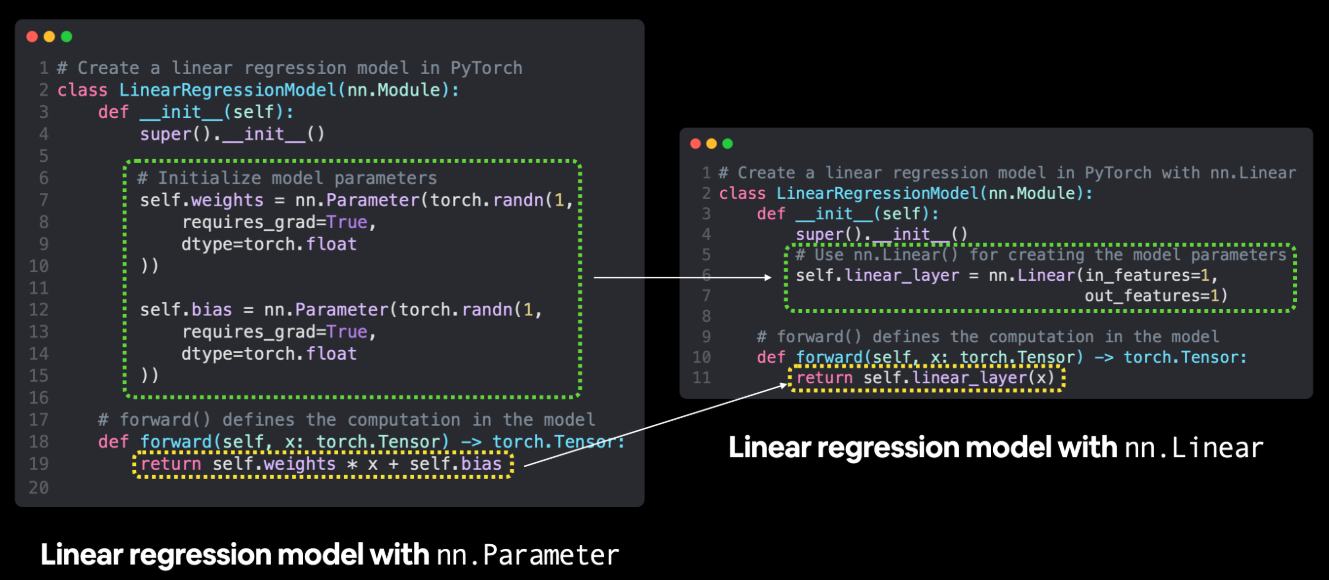

对比使用 nn.Parameter 和使用 nn.Linear 来创建线性回归模型。
torch.nn 模块中还有很多预先构建好的计算层，包括很多常用且实用的神经网络层。

In [6]:
# 继承 nn.Module 来构建我们的模型
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        # 用 nn.Linear() 自动创建模型参数（权重、偏置）
        self.linear_layer = nn.Linear(in_features=1,
                                      out_features=1)

    # 定义前向传播（数据 x 会经过线性层计算）
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

# 设置随机种子，保证每次创建的模型参数一样（方便演示）
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()

model_1.state_dict() 的输出
`nn.Linear()` 层会自动帮我们创建随机的权重（weight）和偏置（bias）参数。

---

将模型移动到 GPU（如果有 GPU 的话）
使用方法：`.to(device)`


In [7]:
# 将模型移动到指定设备（自动用 GPU / CPU）
model_1 = LinearRegressionModelV2().to(device)

# 查看模型现在所在的设备
print("模型所在设备:", next(model_1.parameters()).device)

模型所在设备: cuda:0


### 6.3训练

现在开始构建训练和测试循环，首先需要损失函数和优化器。

我们使用和之前一样的函数：
- 损失函数：`nn.L1Loss()`
- 优化器：`torch.optim.SGD()`

我们必须把新模型的参数（model.parameters()）传给优化器，这样它才能在训练过程中自动调整参数。

之前学习率 0.1 效果很好，所以我们这次也用它。

In [8]:
# 创建损失函数（计算模型预测误差）
loss_fn = nn.L1Loss()

# 创建优化器（更新模型参数）
optimizer = torch.optim.SGD(
    params=model_1.parameters(),  # 优化我们新创建的模型参数
    lr=0.01                      # 学习率：控制参数更新的步长
)

损失函数和优化器已经准备就绪，现在我们用训练+测试循环来训练和评估模型。

这一步和之前训练循环唯一的区别在我们要把数据也放到目标设备上。

我们已经用 model_1.to(device) 把模型放到了设备上。
模型在 GPU，数据也必须在 GPU；
模型在 CPU，数据也必须在 CPU。

这次设置 epochs=1000。

---

PyTorch 训练循环步骤（复习）
   1. 前向传播：模型遍历所有训练数据，执行 forward() 计算
   model(x_train)
   2. 计算损失：对比模型预测值与真实值，计算误差
   loss = loss_fn(y_pred, y_train)
   3. 梯度清零：把优化器的梯度归零（默认会累积）
   optimizer.zero_grad()
   4. 反向传播：计算损失对每个参数的梯度
   loss.backward()
   5. 优化器更新：用梯度下降更新模型参数
   optimizer.step()

In [9]:
# 设置随机种子，保证结果可复现
torch.manual_seed(42)

# 设置训练总轮数
epochs = 1000

# 把数据放到可用的设备上（GPU 或 CPU）
# 不写这行代码会报错（模型和数据必须在同一个设备上）
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

# 开始循环训练
for epoch in range(epochs):
    ### 训练模式 ###
    model_1.train()  # 开启训练模式

    # 1. 前向传播：模型根据输入数据做预测
    y_pred = model_1(X_train)

    # 2. 计算损失：对比预测值和真实值，算误差
    loss = loss_fn(y_pred, y_train)

    # 3. 优化器梯度清零（防止梯度累积）
    optimizer.zero_grad()

    # 4. 反向传播：计算每个参数的梯度
    loss.backward()

    # 5. 优化器更新参数：让模型变得更准
    optimizer.step()

    ### 测试模式 ###
    model_1.eval()  # 切换到评估/推理模式
    # 关闭梯度计算，加快推理速度
    with torch.inference_mode():
        # 1. 前向传播（预测）
        test_pred = model_1(X_test)

        # 2. 计算测试集损失
        test_loss = loss_fn(test_pred, y_test)

    # 每 100 轮打印一次结果
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss} | Test loss: {test_loss}")

Epoch: 0 | Train loss: 0.27326729893684387 | Test loss: 0.22141316533088684
Epoch: 100 | Train loss: 0.17186087369918823 | Test loss: 0.3897513449192047
Epoch: 200 | Train loss: 0.13725484907627106 | Test loss: 0.32007870078086853
Epoch: 300 | Train loss: 0.10290995985269547 | Test loss: 0.24010303616523743
Epoch: 400 | Train loss: 0.06856837123632431 | Test loss: 0.1594388335943222
Epoch: 500 | Train loss: 0.03422487899661064 | Test loss: 0.07946094125509262
Epoch: 600 | Train loss: 0.008531647734344006 | Test loss: 0.005684870760887861
Epoch: 700 | Train loss: 0.008531647734344006 | Test loss: 0.005684870760887861
Epoch: 800 | Train loss: 0.008531647734344006 | Test loss: 0.005684870760887861
Epoch: 900 | Train loss: 0.008531647734344006 | Test loss: 0.005684870760887861


>由于机器学习的随机性，无论你的模型是在 CPU 还是 GPU 上训练，你都可能得到略微不同的结果（不同的损失值和预测值）。即使你在两个设备上使用了相同的随机种子，这种情况也会出现。

如果差异很大，你需要检查代码是否出错；
但如果差异很小（理想情况），直接忽略即可。

让我们看看模型学到了什么参数，
并和我们一开始手动设置的真实参数做个对比。

In [10]:
# 查看模型学习到的参数
from pprint import pprint  # pprint = 美化打印输出
print("模型学习到的权重 和 偏置：")
pprint(model_1.state_dict())  # 打印模型内部的参数
print("\n真实的权重 和 偏置：")
print(f"weights: {weight}, bias: {bias}")

模型学习到的权重 和 偏置：
OrderedDict([('linear_layer.weight', tensor([[0.6985]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3091], device='cuda:0'))])

真实的权重 和 偏置：
weights: 0.7, bias: 0.3


### 6.4 进行预测

我们已经有了训练好的模型，现在把它切换到评估模式，然后开始做预测。

In [11]:
# 开启评估模式
model_1.eval()

# 关闭梯度计算（推理时用，更快、更省内存）
with torch.inference_mode():
    # 用测试集做预测
    y_preds = model_1(X_test)

# 查看预测结果
y_preds

tensor([[0.8679],
        [0.8819],
        [0.8959],
        [0.9098],
        [0.9238],
        [0.9378],
        [0.9517],
        [0.9657],
        [0.9797],
        [0.9937]], device='cuda:0')

如果你用 GPU 上的数据做预测，你可能会注意到上面的输出最后带有 device='cuda:0'。
这表示数据在 CUDA 设备 0 上（因为是从零开始索引，所以这是你的系统能使用的第一张 GPU）。
如果你以后使用多张 GPU，这个数字可能会更高。

现在我们来绘制模型的预测结果。

>Note: 许多数据科学库（例如 pandas、matplotlib 和 NumPy）无法使用存储在 GPU 上的数据。 因此，在尝试使用这些库之一中的函数时，您可能会遇到一些问题，如张量数据未存储在 CPU 上。 为了解决这个问题，用 .cpu() 复制数据到cpu上。

In [ ]:
plot_predictions(y_preds.cpu())

### 6.5 保存和下载模型

In [12]:
from pathlib import Path

# 1. 创建存储模型的文件夹
MODEL_PATH = Path(r"D:\Programming language\pytorch\pytorch-playground\models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)  # exist_ok=True：如果文件夹已存在，不会报错

# 2. 创建模型保存的完整路径（文件名）
MODEL_NAME = "01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. 保存模型学到的参数
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(
    obj=model_1.state_dict(),  # 只保存模型学习到的参数（最常用、最轻便）
    f=MODEL_SAVE_PATH
)

Saving model to: D:\Programming language\pytorch\pytorch-playground\models\01_pytorch_workflow_model_1.pth


为了确保一切正常，我们把保存的模型重新加载回来。

   1. 创建一个新的 LinearRegressionModelV2() 实例
   2. 使用 torch.nn.Module.load_state_dict() 加载保存的模型参数
   3. 把新模型放到目标设备上（保证代码不依赖特定设备）

In [13]:
# 1. 创建一个全新的模型实例
loaded_model_1 = LinearRegressionModelV2()

# 2. 加载之前保存的模型参数（权重、偏置）
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

# 3. 把模型放到指定设备（CPU/GPU）
# 重要：数据在哪个设备，模型就必须在哪个设备，否则预测会报错
loaded_model_1.to(device)

# 打印加载好的模型
print(f"加载后的模型:\n{loaded_model_1}")
# 查看模型在哪个设备上
print(f"模型所在设备:\n{next(loaded_model_1.parameters()).device}")

加载后的模型:
LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)
模型所在设备:
cuda:0


现在我们可以评估加载回来的模型，看看它的预测结果是否和保存之前的模型完全一致。

（如果一致，说明模型保存 & 加载完全成功！）

In [14]:
# 开启评估模式
loaded_model_1.eval()

# 关闭梯度，进行推理预测
with torch.inference_mode():
    # 用加载好的模型做预测
    loaded_model_preds = loaded_model_1(X_test)

# 对比之前的预测结果 和 加载后模型的预测结果
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')